Probability at 12 yards: 0.7546666666666667


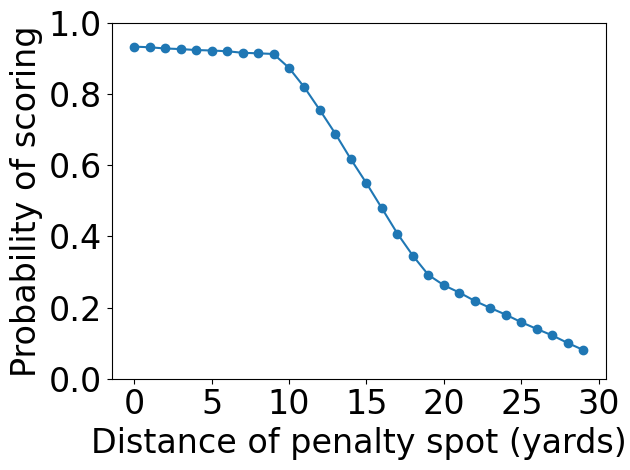

In [ ]:
import random
import math
import matplotlib.pyplot as plt

GOAL_WIDTH = 24
GOAL_HEIGHT = 8

KEEPER_X = GOAL_WIDTH / 2
KEEPER_Y = 3

BALL_SPEED = 110
REACTION_TIME = 0.25
DIVE_SPEED = 16
ARM_REACH = 2


def keeper_radius(distance):
    travel_time = distance / BALL_SPEED
    move_time = max(0, travel_time - REACTION_TIME)
    return ARM_REACH + DIVE_SPEED * move_time


def scoring_probability(distance_ft, trials=150000):

    r = keeper_radius(distance_ft)
    saves = 0

    for _ in range(trials):

        x = random.uniform(0, GOAL_WIDTH)
        y = random.uniform(0, GOAL_HEIGHT)

        shot_left = x < GOAL_WIDTH / 2

        guess_prob = min(0.5, distance_ft / 80)

        if random.random() < guess_prob:
            keeper_x = KEEPER_X + (-r if shot_left else r)
        else:
            keeper_x = KEEPER_X

        keeper_y = KEEPER_Y

        d = math.sqrt((x - keeper_x) ** 2 + (y - keeper_y) ** 2)

        if d <= r:
            saves += 1

    return 1 - saves / trials


print("Probability at 12 yards:", scoring_probability(36))


distances = list(range(0, 30))
probs = [scoring_probability(d * 3) for d in distances]

plt.figure()
plt.plot(distances, probs)
plt.scatter(distances, probs)

plt.xlabel("Distance of penalty spot (yards)",fontsize=24)
plt.ylabel("Probability of scoring",fontsize=24)
plt.ylim(0, 1)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.tight_layout()
plt.savefig("scoring_probability.pdf")
plt.show()